
# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc


### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [2]:
df = pd.read_csv('Car_sales.csv')

df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

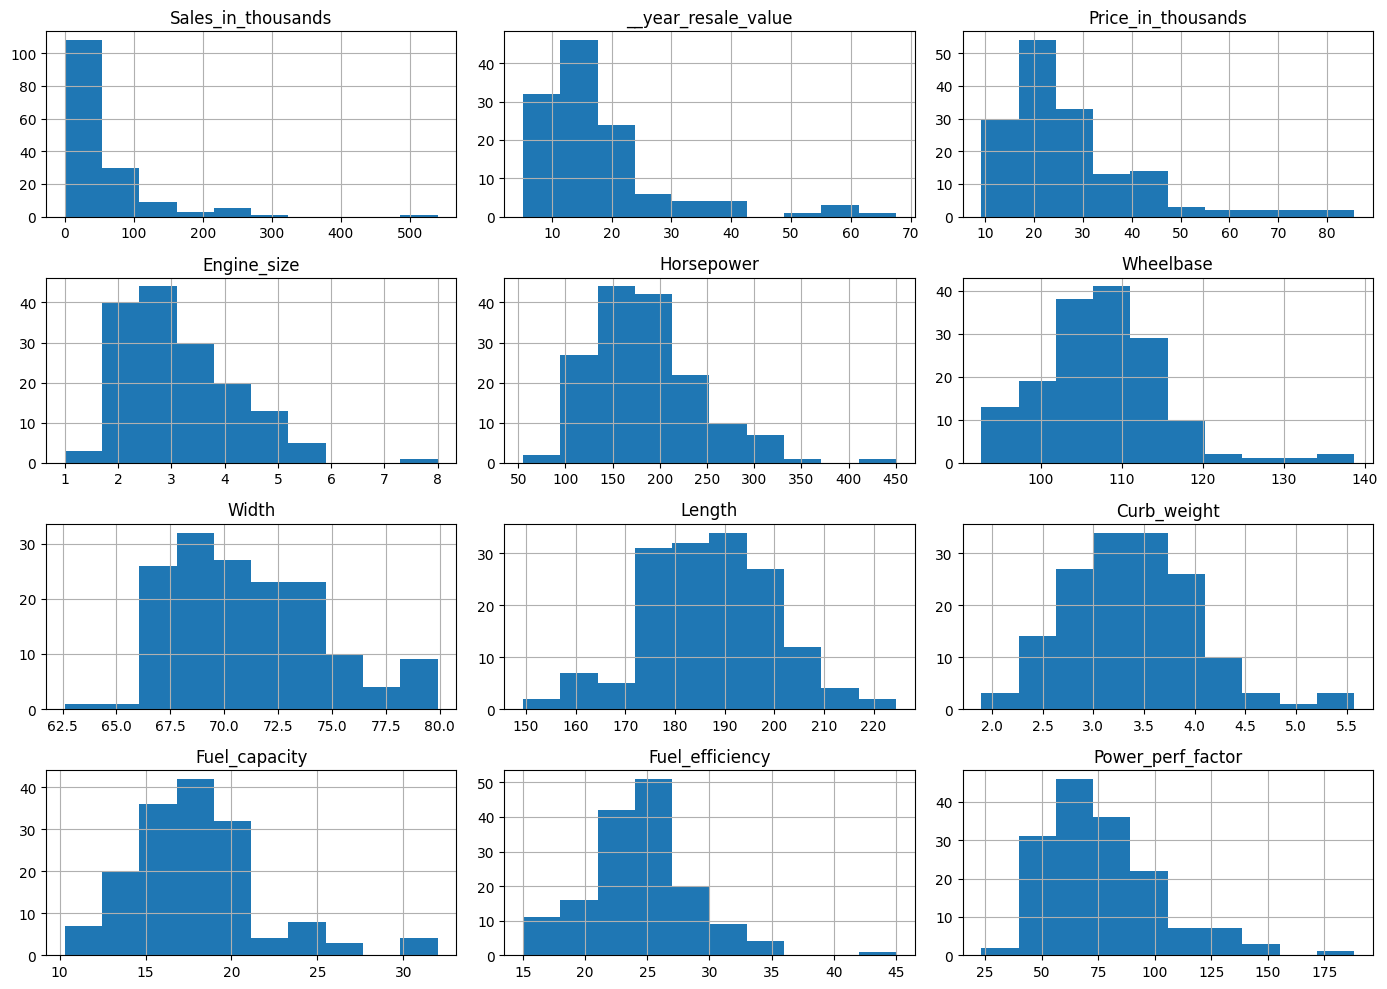

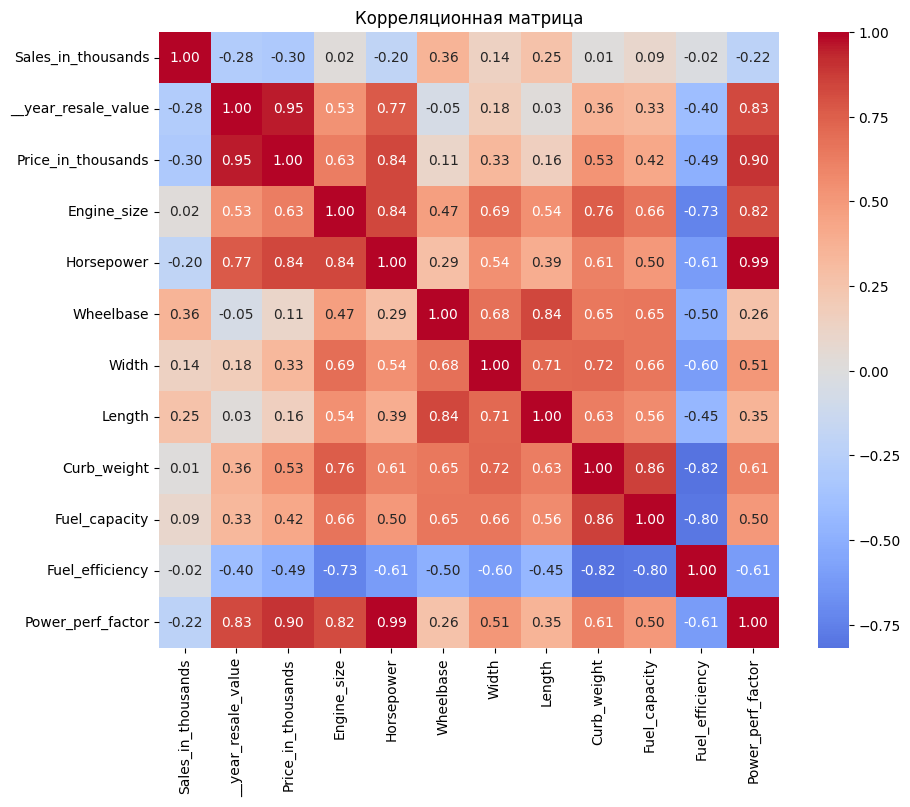

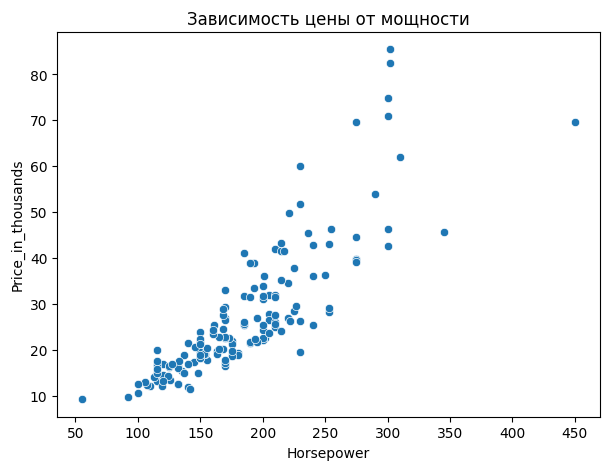

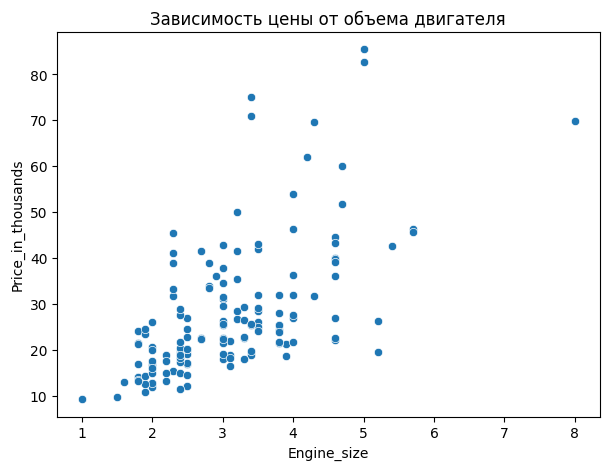

In [3]:
print(df.info())
print(df.isnull().sum())

num = df.select_dtypes(include=np.number)

num.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

corr = num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Horsepower', y='Price_in_thousands')
plt.title('Зависимость цены от мощности')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Engine_size', y='Price_in_thousands')
plt.title('Зависимость цены от объема двигателя')
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [5]:
df = df.dropna(subset=['Price_in_thousands'])

num = df.select_dtypes(include=np.number)
X = num.drop('Price_in_thousands', axis=1)
y = df['Price_in_thousands']

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((108, 11), (47, 11))

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [6]:
models = {}

model = LinearRegression()
model.fit(X_train, y_train)
models['Linear Regression'] = model

params = {
    'alpha': np.logspace(-4, 4, 50)
}

grid = GridSearchCV(Ridge(), params, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)
models['Ridge'] = grid.best_estimator_

random = RandomizedSearchCV(
    Lasso(max_iter=10000),
    params,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
random.fit(X_train, y_train)
models['Lasso'] = random.best_estimator_

params_en = {
    'alpha': np.logspace(-4, 4, 20),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

grid_en = GridSearchCV(
    ElasticNet(max_iter=10000),
    params_en,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_en.fit(X_train, y_train)
models['ElasticNet'] = grid_en.best_estimator_

print('Ridge:', grid.best_params_)
print('Lasso:', random.best_params_)
print('ElasticNet:', grid_en.best_params_)

Ridge: {'alpha': np.float64(0.0001)}
Lasso: {'alpha': np.float64(0.013257113655901081)}
ElasticNet: {'alpha': np.float64(0.004832930238571752), 'l1_ratio': np.float64(0.1)}


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [7]:
results = []

for name, model in models.items():
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mse, rmse, mae, r2])

results = pd.DataFrame(
    results,
    columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2']
)

results

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,6.836460e-16,2.614662e-08,1.634823e-08,1.000000
1,Ridge,2.714151e-12,1.647468e-06,1.138299e-06,1.000000
2,Lasso,8.723113e-04,2.953492e-02,2.249017e-02,0.999996
3,ElasticNet,5.040905e-04,2.245196e-02,1.645764e-02,0.999998


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



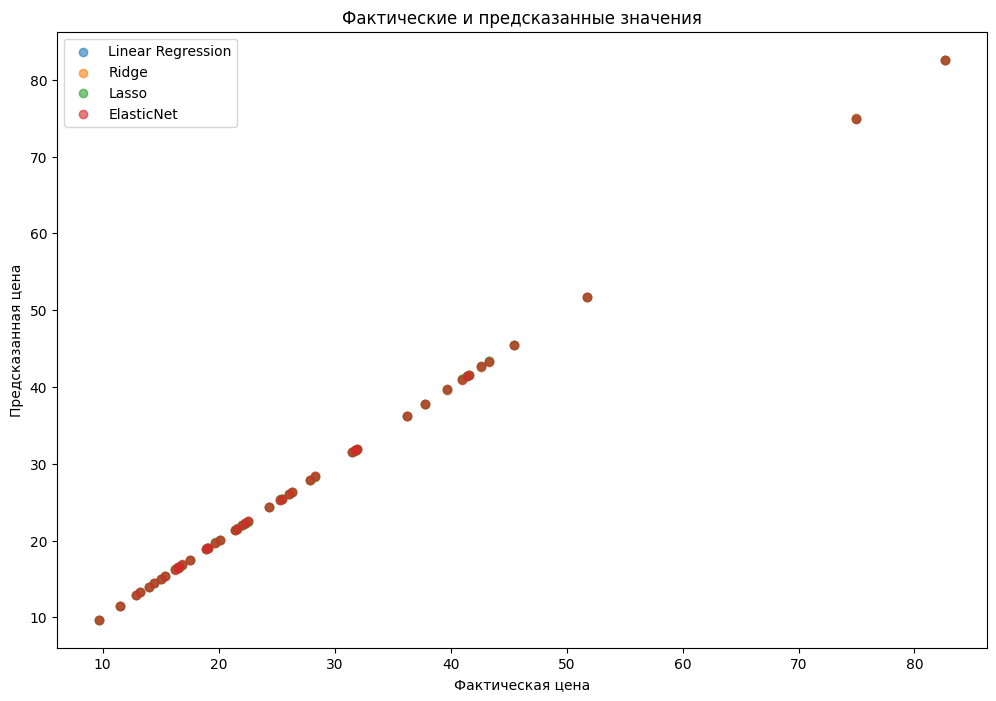

In [8]:
plt.figure(figsize=(12, 8))

for name, model in models.items():
    pred = model.predict(X_test)
    plt.scatter(y_test, pred, label=name, alpha=0.6)

plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Фактические и предсказанные значения')
plt.legend()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [9]:
best_name = results.loc[results['R2'].idxmax(), 'Model']
best_model = models[best_name]

print('Лучшая модель:', best_name)
print(results[results['Model'] == best_name])

if best_name == 'Ridge':
    print('Параметры:', grid.best_params_)
elif best_name == 'Lasso':
    print('Параметры:', random.best_params_)
elif best_name == 'ElasticNet':
    print('Параметры:', grid_en.best_params_)

Лучшая модель: Linear Regression
               Model           MSE          RMSE           MAE   R2
0  Linear Regression  6.836460e-16  2.614662e-08  1.634823e-08  1.0


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [10]:
df = pd.read_csv('climate_change_impact_on_agriculture_2024.csv')

df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72





- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  str    
 2   Region                       10000 non-null  str    
 3   Crop_Type                    10000 non-null  str    
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strategies       

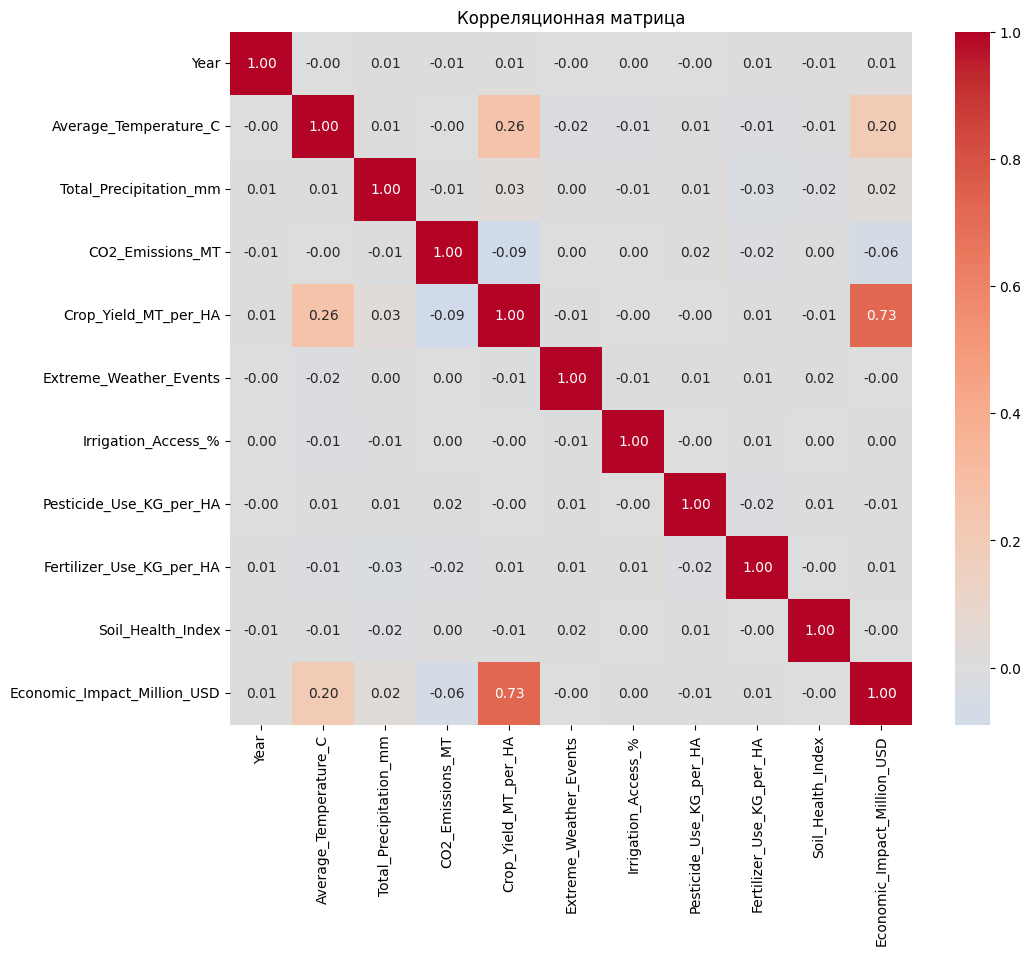

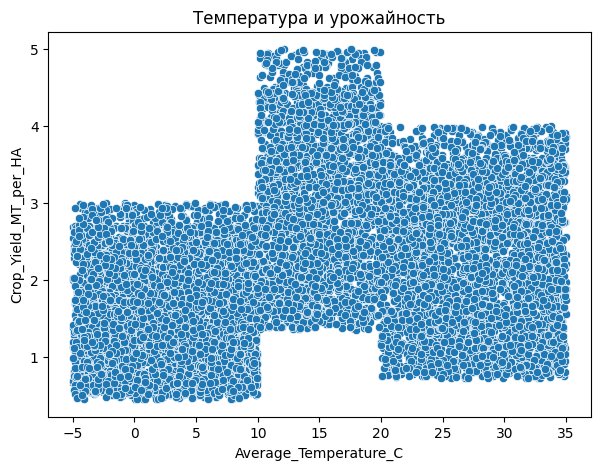

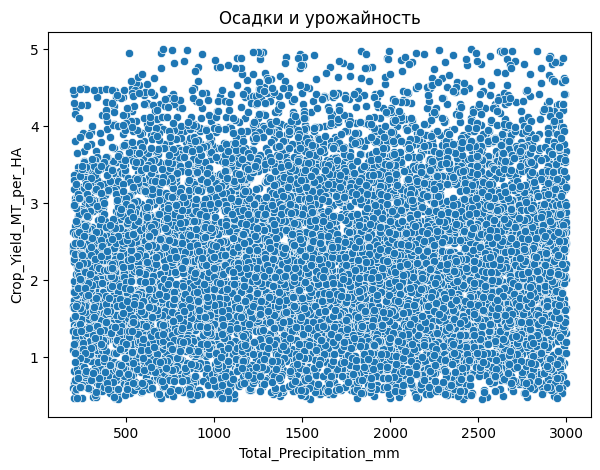

In [11]:
print(df.info())
print(df.isnull().sum())

num = df.select_dtypes(include=np.number)

corr = num.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Average_Temperature_C', y='Crop_Yield_MT_per_HA')
plt.title('Температура и урожайность')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Total_Precipitation_mm', y='Crop_Yield_MT_per_HA')
plt.title('Осадки и урожайность')
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [12]:
df = df.dropna(subset=['Crop_Yield_MT_per_HA'])

num = df.select_dtypes(include=np.number)
X = num.drop('Crop_Yield_MT_per_HA', axis=1)
y = df['Crop_Yield_MT_per_HA']

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((7000, 10), (3000, 10))



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [13]:
models = {}

model = LinearRegression()
model.fit(X_train, y_train)
models['Linear Regression'] = model

params = {
    'alpha': np.logspace(-4, 4, 50)
}

random = RandomizedSearchCV(
    Ridge(),
    params,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
random.fit(X_train, y_train)
models['Ridge'] = random.best_estimator_

grid = GridSearchCV(
    Lasso(max_iter=10000),
    params,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid.fit(X_train, y_train)
models['Lasso'] = grid.best_estimator_

params_en = {
    'alpha': np.logspace(-4, 4, 20),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

grid_en = GridSearchCV(
    ElasticNet(max_iter=10000),
    params_en,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_en.fit(X_train, y_train)
models['ElasticNet'] = grid_en.best_estimator_

print('Ridge:', random.best_params_)
print('Lasso:', grid.best_params_)
print('ElasticNet:', grid_en.best_params_)

Ridge: {'alpha': np.float64(6866.488450042998)}
Lasso: {'alpha': np.float64(0.08685113737513521)}
ElasticNet: {'alpha': np.float64(0.08858667904100823), 'l1_ratio': np.float64(0.9)}


- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [14]:
results = []

for name, model in models.items():
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mse, rmse, mae, r2])

results = pd.DataFrame(
    results,
    columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2']
)

results

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.450370,0.671096,0.541284,0.557784
1,Ridge,0.450312,0.671053,0.541265,0.557842
2,Lasso,0.449709,0.670603,0.540986,0.558434
3,ElasticNet,0.449715,0.670608,0.540994,0.558427




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

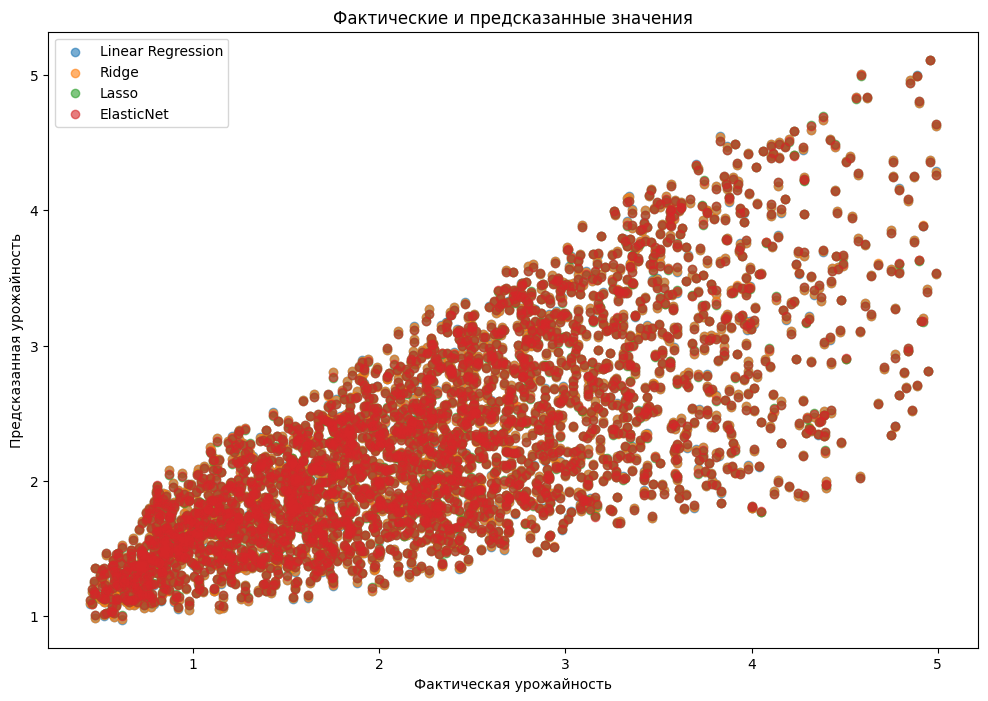

In [15]:
plt.figure(figsize=(12, 8))

for name, model in models.items():
    pred = model.predict(X_test)
    plt.scatter(y_test, pred, label=name, alpha=0.6)

plt.xlabel('Фактическая урожайность')
plt.ylabel('Предсказанная урожайность')
plt.title('Фактические и предсказанные значения')
plt.legend()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [16]:
best_name = results.loc[results['R2'].idxmax(), 'Model']
best_model = models[best_name]

print('Лучшая модель:', best_name)
print(results[results['Model'] == best_name])

if best_name == 'Ridge':
    print('Параметры:', random.best_params_)
elif best_name == 'Lasso':
    print('Параметры:', grid.best_params_)
elif best_name == 'ElasticNet':
    print('Параметры:', grid_en.best_params_)

Лучшая модель: Lasso
   Model       MSE      RMSE       MAE        R2
2  Lasso  0.449709  0.670603  0.540986  0.558434
Параметры: {'alpha': np.float64(0.08685113737513521)}


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



CO2_Emissions_MT              -0.004296
Soil_Health_Index             -0.000198
Irrigation_Access_%           -0.000061
Fertilizer_Use_KG_per_HA      -0.000008
Extreme_Weather_Events        -0.000000
Pesticide_Use_KG_per_HA        0.000000
Year                           0.000000
Total_Precipitation_mm         0.000019
Economic_Impact_Million_USD    0.001672
Average_Temperature_C          0.010945
dtype: float64


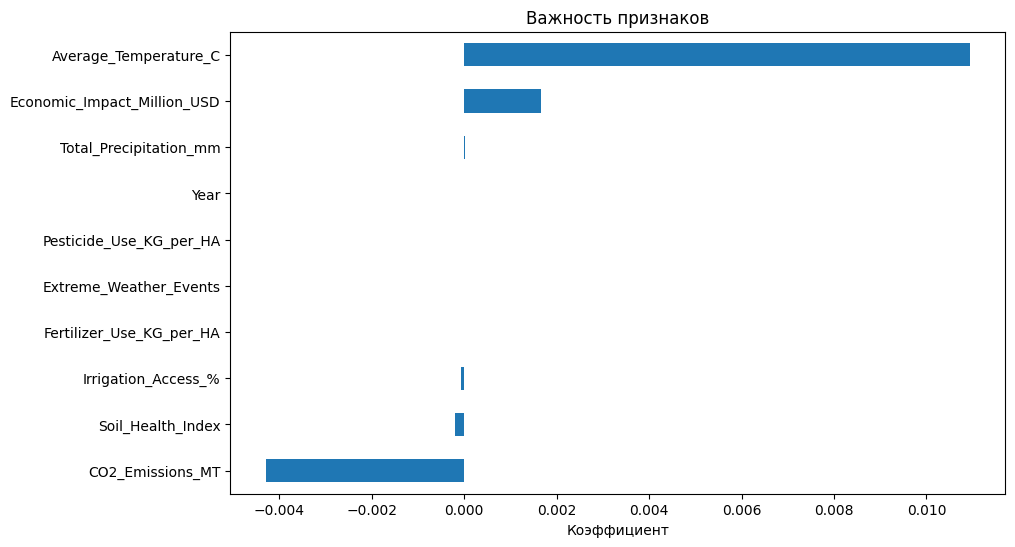

In [17]:
coef = pd.Series(best_model.coef_, index=X.columns).sort_values()

print(coef)

plt.figure(figsize=(10, 6))
coef.plot(kind='barh')
plt.title('Важность признаков')
plt.xlabel('Коэффициент')
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**


На основе коэффициентов модели можно определить направление влияния признаков.

Положительный коэффициент означает увеличение прогнозируемой урожайности при увеличении признака, отрицательный — уменьшение при прочих равных условиях.

На основе коэффициентов лучшей модели можно определить, какие признаки связаны с увеличением и уменьшением урожайности. 
Признаки с положительными коэффициентами имеют положительное влияние на прогноз урожайности, а с отрицательными коэффициентами — отрицательное.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [19]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [20]:
print(df.info())
print(df.isnull().sum())

df = df.dropna()

df['y'] = df['y'].map({'yes': 1, 'no': 0})

X = df.drop('y', axis=1)
y = df['y']

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X.head()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.533034,0.010471,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
1,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
2,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
3,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857
4,1.533034,0.187888,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067,0.397706,-0.1857


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((28831, 53), (12357, 53))

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [28]:
models = {}

params = {
    'C': np.logspace(-4, 4, 10)
}

grid = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=300),
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
models['L2'] = grid.best_estimator_

random = RandomizedSearchCV(
    LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=100,
        tol=1e-2
    ),
    params,
    n_iter=3,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random.fit(X_train, y_train)
models['L1'] = random.best_estimator_

params_en = {
    'C': np.logspace(-4, 4, 10),
    'l1_ratio': np.linspace(0.1, 0.9, 5)
}

random_en = RandomizedSearchCV(
    LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=100,
        tol=1e-2
    ),
    params_en,
    n_iter=3,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_en.fit(X_train, y_train)
models['ElasticNet'] = random_en.best_estimator_

print('L2:', grid.best_params_)
print('L1:', random.best_params_)
print('ElasticNet:', random_en.best_params_)

c:\Users\pasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\pasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


L2: {'C': np.float64(2.782559402207126)}
L1: {'C': np.float64(1291.5496650148827)}
ElasticNet: {'l1_ratio': np.float64(0.9), 'C': np.float64(166.81005372000558)}



- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

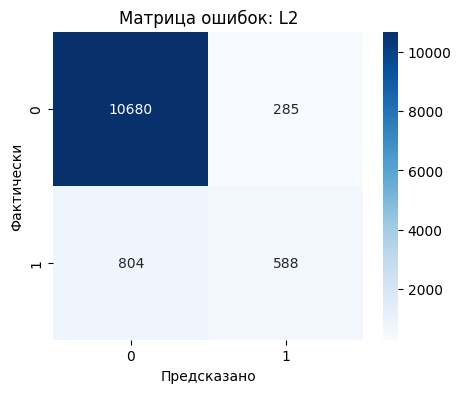

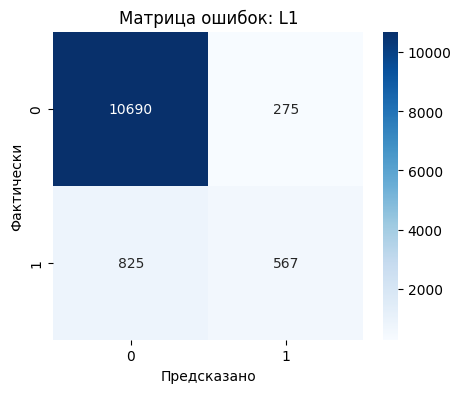

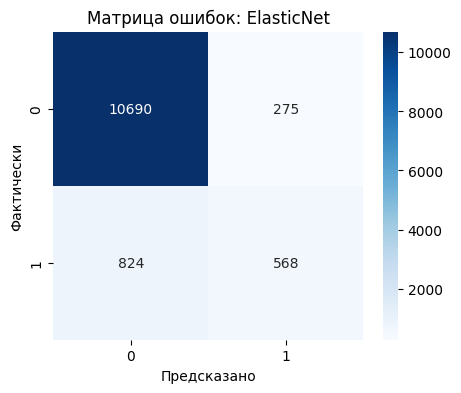

,Model,Accuracy,Precision,Recall,F1
0,L2,0.911872,0.673540,0.422414,0.519205
1,L1,0.910982,0.673397,0.407328,0.507610
2,ElasticNet,0.911063,0.673784,0.408046,0.508277


In [31]:
results = []

for name, model in models.items():
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([name, accuracy, precision, recall, f1])

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок: ' + name)
    plt.xlabel('Предсказано')
    plt.ylabel('Фактически')
    plt.show()

results = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
)

results

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



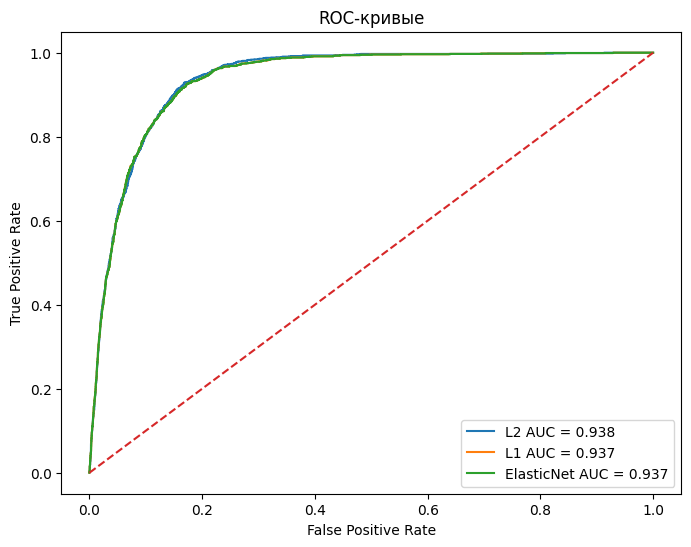

In [32]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=name + ' AUC = ' + str(round(roc_auc, 3)))

plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [33]:
auc_results = []

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    auc_results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc
    ])

results = pd.DataFrame(
    auc_results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
)

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,L2,0.911872,0.673540,0.422414,0.519205,0.938288
1,L1,0.910982,0.673397,0.407328,0.507610,0.936889
2,ElasticNet,0.911063,0.673784,0.408046,0.508277,0.936879
